# 📐 Class 11.4 — ARIMA & SARIMA
### 301 – ML Techniques | Week 11

**Learning Goals:** Read ACF/PACF plots, use auto_arima to select p,d,q, fit SARIMA for seasonal data, compare against Holt-Winters and RandomForest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (13, 5)
print('✅ Ready')
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
try:
    from pmdarima import auto_arima
except ImportError:
    import subprocess; subprocess.run(['pip','install','pmdarima','-q'])
    from pmdarima import auto_arima

✅ Ready



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Airline passengers (with chronological split)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Passengers']

# Chronological split — 80/20
split_idx = int(len(df) * 0.8)
train = df['Passengers'].iloc[:split_idx]
test  = df['Passengers'].iloc[split_idx:]
print(f'Train: {len(train)}  Test: {len(test)}')

# Log transform
log_train = np.log(train)
log_test  = np.log(test)

Train: 115  Test: 29


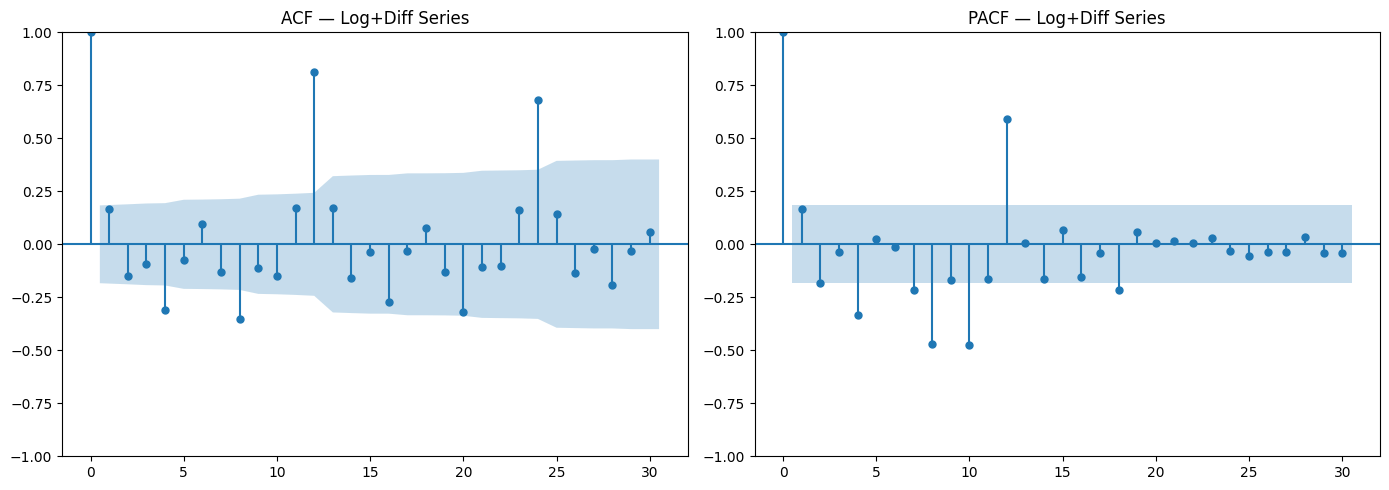

HOW TO READ ACF/PACF:
ACF spikes  → suggest MA(q) order — look where it cuts off significantly
PACF spikes → suggest AR(p) order — look where it cuts off significantly
Blue shaded region = 95% confidence interval

From the plots, estimated p=1, d=1, q=1  (a typical ARIMA(1,1,1) starting point;
seasonal spikes near lag 12 suggest also adding seasonal SARIMA terms)


In [3]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(log_train.diff().dropna(),  lags=30, ax=axes[0], title='ACF — Log+Diff Series')
plot_pacf(log_train.diff().dropna(), lags=30, ax=axes[1], title='PACF — Log+Diff Series')
plt.tight_layout(); plt.show()

print('HOW TO READ ACF/PACF:')
print('ACF spikes  → suggest MA(q) order — look where it cuts off significantly')
print('PACF spikes → suggest AR(p) order — look where it cuts off significantly')
print('Blue shaded region = 95% confidence interval')
print()
print('From the plots, estimated p=1, d=1, q=1  (a typical ARIMA(1,1,1) starting point;')
print('seasonal spikes near lag 12 suggest also adding seasonal SARIMA terms)')


In [4]:
# auto_arima — "GridSearchCV for ARIMA parameters"
print('Running auto_arima (this may take 1-2 minutes)...')
auto_model = auto_arima(log_train, seasonal=True, m=12,
                         information_criterion='aic', stepwise=True, verbose=False)
print(f'Best model: {auto_model.order} x {auto_model.seasonal_order}')
print(auto_model.summary())


Running auto_arima (this may take 1-2 minutes)...
Best model: (2, 0, 0) x (0, 1, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  115
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 194.477
Date:                              Tue, 05 May 2026   AIC                           -378.954
Time:                                      18:10:57   BIC                           -365.780
Sample:                                  01-01-1949   HQIC                          -373.618
                                       - 07-01-1958                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept 

SARIMA MAE: 33.4 passengers


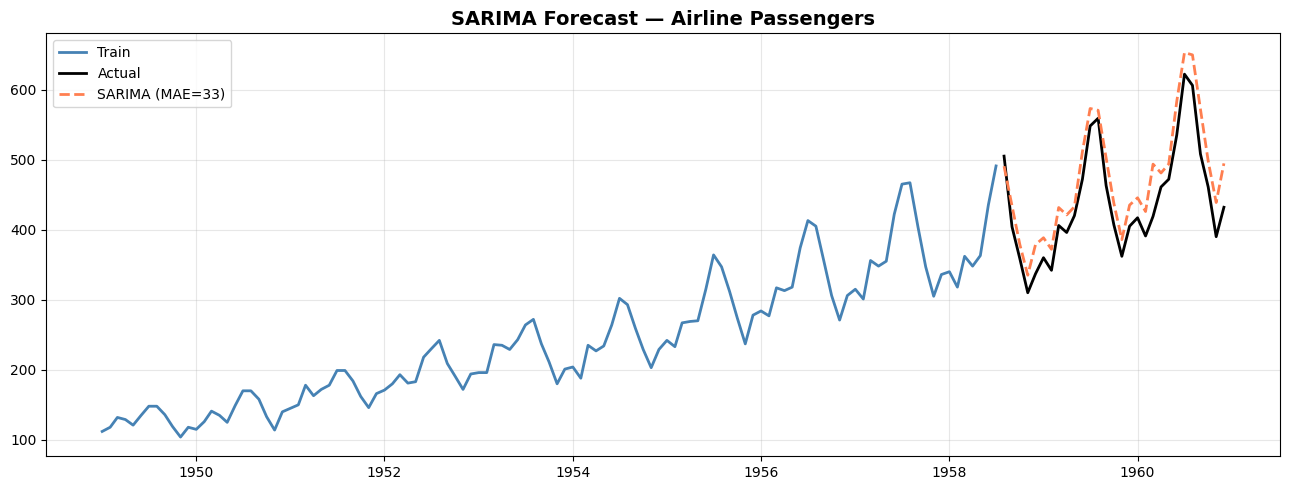

In [5]:
# Forecast and evaluate
n_test = len(test)
log_preds    = auto_model.predict(n_periods=n_test)
preds_sarima = np.exp(log_preds)

mae_sarima = mean_absolute_error(test, preds_sarima)
print(f'SARIMA MAE: {mae_sarima:.1f} passengers')

plt.figure(figsize=(13, 5))
plt.plot(train.index, train, color='steelblue', linewidth=2, label='Train')
plt.plot(test.index,  test,  color='black',     linewidth=2, label='Actual')
plt.plot(test.index, preds_sarima, color='coral', linewidth=2, linestyle='--',
         label=f'SARIMA (MAE={mae_sarima:.0f})')
plt.title('SARIMA Forecast — Airline Passengers', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## ✅ Complete!

- **ARIMA(p,d,q)**: p=AR lags, d=differencing order, q=MA lags
- **SARIMA**: adds seasonal P,D,Q,m components
- **auto_arima**: searches for best p,d,q automatically — like GridSearchCV
- **ACF/PACF**: manual method for choosing p and q (auto_arima makes this optional)